## Background

The purpose of this notebook is to quantify vegetation condition and greenness over a defined area of interest (AOI), using Sentinel-2 surface reflectance.

### Objectives:
1. Load cloud-free Sentinel-2 Level 2A imagery for chosen AOI and time period.
2. Apply the correct reflectance scaling (offset) for the product used.
3. Calculate four vegetation indices - NDVI, EVI, SAVI, MSAVI. each suited to slightly differentiate vegetation and soil conditions.
4. Reduce the times series to a single median composite to minimise residual noise.

### Expected outputs:
1. A summary statistics including mean, standard deviation, minimum and maximum per index.
2. A 4-panel PNG figure comparing NDVI, EVI, SAVI and MSAVI over the AOI.


**Data used:** Sentinel-2 Level-2A Collection 1 (`s2_l2a_c1`) from the [Digital Earth Africa](https://www.digitalearthafrica.org/) datacube. Bands: red, green, blue, NIR, SWIR-1.6, and the SCL (scene classification) layer.


## Load packages

In [1]:
import datacube
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from odc.ui import with_ui_cbk

from deafrica_tools.plotting import rgb
from deafrica_tools.plotting import display_map
from deafrica_tools.datahandling import load_ard
from deafrica_tools.bandindices import calculate_indices

## Connect to the datacube

In [2]:
dc = datacube.Datacube(app='Sentinel-2')

## Product measurement and availability
We can use datacube's list_products functionality to inspect the DE Africa's Sentinel-2 products that are available in the datacube. The table below shows the product names that we will use to load the data, a brief description of the data, and the satellite instrument that acquired the data.

In [3]:
# List Sentinel-2 products available in DE Africa
dc_products = dc.list_products()
display_columns = ['name', 'description']
dc_products[dc_products.name.str.contains(
    's2_l2a').fillna(
        False)][display_columns].set_index('name')

,description
name,
s2_l2a,"Sentinel-2a and Sentinel-2b imagery, processed..."
s2_l2a_c1,ESA Sentinel-2A and Sentinel-2B Collection 1 L...


## List measurements
We can further inspect the data available for the Sentinel-2 c1 using datacube's `list_products` functionality. The table below lists each of the measurements available in the data.

In [4]:
dc_measurements = dc.list_measurements()
dc_measurements.loc['s2_l2a_c1']

,name,dtype,units,nodata,aliases,flags_definition,add_offset,scale_factor
measurement,,,,,,,,
coastal,coastal,uint16,1,0.0,"[band_01, coastal_aerosol, B01]",NaN,-1000.0,NaN
blue,blue,uint16,1,0.0,"[band_02, B02]",NaN,-1000.0,NaN
green,green,uint16,1,0.0,"[band_03, B03]",NaN,-1000.0,NaN
red,red,uint16,1,0.0,"[band_04, B04]",NaN,-1000.0,NaN
rededge1,rededge1,uint16,1,0.0,"[band_05, red_edge_1, B05]",NaN,-1000.0,NaN
rededge2,rededge2,uint16,1,0.0,"[band_06, red_edge_2, B06]",NaN,-1000.0,NaN
rededge3,rededge3,uint16,1,0.0,"[band_07, red_edge_3, B07]",NaN,-1000.0,NaN
nir,nir,uint16,1,0.0,"[band_08, nir_1, B08]",NaN,-1000.0,NaN
nir08,nir08,uint16,1,0.0,"[band_8a, nir_narrow, nir_2, B8A]",NaN,-1000.0,NaN


## Load Sentinel-2 data
We can load data from the datacube using `dc.load()`.

In the example below, we will load data from Sentinel-2 Collection 1 from Ahero, Kenya in December 2025. We will load data from five spectral satellite bands, as well as cloud masking data ('SCL'). By specifying output_crs='EPSG:32636' and resolution=(-10, 10), we request that datacube reproject our data to UTM Zone 36N (CRS), which covers western part of Kenya, with 10 x 10 m pixels. Finally, group_by='solar_day' ensures that overlapping images taken within seconds of each other as the satellite passes over are combined into a single time step in the data.


In [5]:
#Store the measurements in the bands variable
bands = ['red', 'green', 'blue', 'nir', 'swir16', 'scl']
time_range = ("2025-12", "2025-12")
resolution = (-10, 10)

# load data
ds_load = dc.load(
    product="s2_l2a_c1",
    measurements=bands,
    y=(-0.18, -0.12),
    x=(34.88, 34.98),
    time=time_range,
    resolution=resolution,
    output_crs='EPSG:32636',
    group_by="solar_day",
)


In [6]:
ds_load

<xarray.Dataset> Size: 81MB
Dimensions:      (time: 10, y: 664, x: 1114)
Coordinates:
  * time         (time) datetime64[ns] 80B 2025-12-01T08:10:05.478000 ... 202...
  * y            (y) float64 5kB -1.328e+04 -1.328e+04 ... -1.99e+04 -1.99e+04
  * x            (x) float64 9kB 7.092e+05 7.092e+05 ... 7.204e+05 7.204e+05
    spatial_ref  int32 4B 32636
Data variables:
    red          (time, y, x) uint16 15MB 1756 1954 1922 1854 ... 2013 2058 2142
    green        (time, y, x) uint16 15MB 1952 1978 1788 1816 ... 2186 2096 2086
    blue         (time, y, x) uint16 15MB 1646 1710 1680 1642 ... 1960 1930 1955
    nir          (time, y, x) uint16 15MB 3942 3614 2781 3093 ... 3918 3554 3112
    swir16       (time, y, x) uint16 15MB 3121 3268 3268 3134 ... 3691 3691 3592
    scl          (time, y, x) uint8 7MB 10 10 10 10 10 10 ... 10 10 10 10 10 10
Attributes:
    crs:           EPSG:32636
    grid_mapping:  spatial_ref

In [7]:
offset_value = dc_measurements.loc['s2_l2a_c1'].filter(items=bands, axis='index').add_offset.fillna(0)
ds_load = ds_load + offset_value

In [8]:
ds_load

<xarray.Dataset> Size: 355MB
Dimensions:      (time: 10, y: 664, x: 1114)
Coordinates:
  * time         (time) datetime64[ns] 80B 2025-12-01T08:10:05.478000 ... 202...
  * y            (y) float64 5kB -1.328e+04 -1.328e+04 ... -1.99e+04 -1.99e+04
  * x            (x) float64 9kB 7.092e+05 7.092e+05 ... 7.204e+05 7.204e+05
    spatial_ref  int32 4B 32636
Data variables:
    red          (time, y, x) float64 59MB 756.0 954.0 ... 1.058e+03 1.142e+03
    green        (time, y, x) float64 59MB 952.0 978.0 ... 1.096e+03 1.086e+03
    blue         (time, y, x) float64 59MB 646.0 710.0 680.0 ... 930.0 955.0
    nir          (time, y, x) float64 59MB 2.942e+03 2.614e+03 ... 2.112e+03
    swir16       (time, y, x) float64 59MB 2.121e+03 2.268e+03 ... 2.592e+03
    scl          (time, y, x) float64 59MB 10.0 10.0 10.0 ... 10.0 10.0 10.0
Attributes:
    crs:           EPSG:32636
    grid_mapping:  spatial_ref

## Plotting Sentinel-2 data
We can plot the data we loaded using the rgb function. By default, the function will plot data as a true colour image using the 'red', 'green', and 'blue' bands.

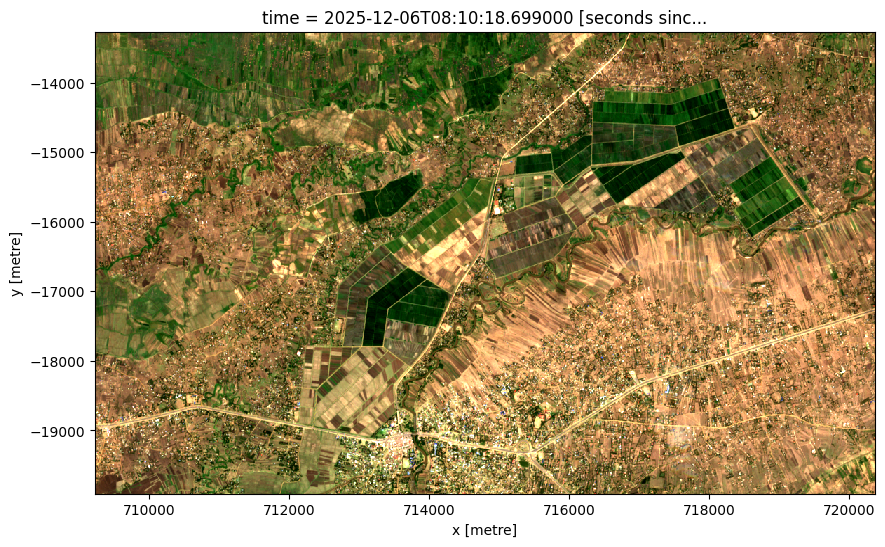

In [9]:
rgb(ds_load, index=[1])

## Calculate vegetation indices
`calculate_indices()` computes four indices, each useful in different conditions:

| Index | Formula | Best suited for |
|---|---|---|
| **NDVI** | $\frac{NIR - Red}{NIR + Red}$ | General vegetation greenness, the standard. Most widely used index |
| **EVI** | $2.5 \times \frac{NIR - Red}{NIR + 6Red - 7.5Blue + 1}$ | High-biomass canopies; more resistant to atmospheric/soil noise |
| **SAVI** | $\frac{NIR - Red}{NIR + Red + L}(1+L)$, $L=0.5$ | Cropland/sparse cover with visible soil background |
| **MSAVI** | $\frac{2NIR+1-\sqrt{(2NIR+1)^2-8(NIR-Red)}}{2}$ | Sparse vegetation/bare soil |

In [10]:
ds_load = calculate_indices(
    ds_load,
    index=['NDVI', 'EVI', 'SAVI', 'MSAVI'],
    satellite_mission='s2',
    drop=False,
)

index_names = ['NDVI', 'EVI', 'SAVI', 'MSAVI']
print(ds_load[index_names])

<xarray.Dataset> Size: 237MB
Dimensions:      (time: 10, y: 664, x: 1114)
Coordinates:
  * time         (time) datetime64[ns] 80B 2025-12-01T08:10:05.478000 ... 202...
  * y            (y) float64 5kB -1.328e+04 -1.328e+04 ... -1.99e+04 -1.99e+04
  * x            (x) float64 9kB 7.092e+05 7.092e+05 ... 7.204e+05 7.204e+05
    spatial_ref  int32 4B 32636
Data variables:
    NDVI         (time, y, x) float64 59MB 0.5911 0.4652 ... 0.4142 0.2981
    EVI          (time, y, x) float64 59MB 0.4326 0.3189 ... 0.3136 0.2055
    SAVI         (time, y, x) float64 59MB 0.377 0.2906 0.1673 ... 0.2606 0.1763
    MSAVI        (time, y, x) float64 59MB 0.3543 0.2637 ... 0.2344 0.1528
Attributes:
    crs:           EPSG:32636
    grid_mapping:  spatial_ref


## Build a median composite
Taking the per-pixel median across all time steps reduces the influence of residual cloud, shadow, and noise that individual scenes may still contain.

In [11]:
indices_median = ds_load[index_names].median(dim='time').compute()

print(f"{'Index':>6}  {'Mean':>8}  {'Std':>8}  {'Min':>8}  {'Max':>8}")
print("-" * 46)
summary_rows = []
for name in indices_median.data_vars:
    arr = indices_median[name]
    row = {
        'index': name,
        'mean': float(arr.mean()),
        'std': float(arr.std()),
        'min': float(arr.min()),
        'max': float(arr.max()),
    }
    summary_rows.append(row)
    print(f"{row['index']:>6}  {row['mean']:>8.4f}  {row['std']:>8.4f}  {row['min']:>8.4f}  {row['max']:>8.4f}")

summary_df = pd.DataFrame(summary_rows).set_index('index')

 Index      Mean       Std       Min       Max
----------------------------------------------
  NDVI    0.4195    0.1484   -0.1586    0.8935
   EVI    0.2554    0.1067   -0.0861    1.2017
  SAVI    0.2392    0.0945   -0.0754    0.6821
 MSAVI    0.2143    0.0961   -0.0588    0.7545


## Plot all four indices
Each panel is titled with its index name and mean value, sharing a common scale **(-0.1 to 1.0)** for direct comparison.

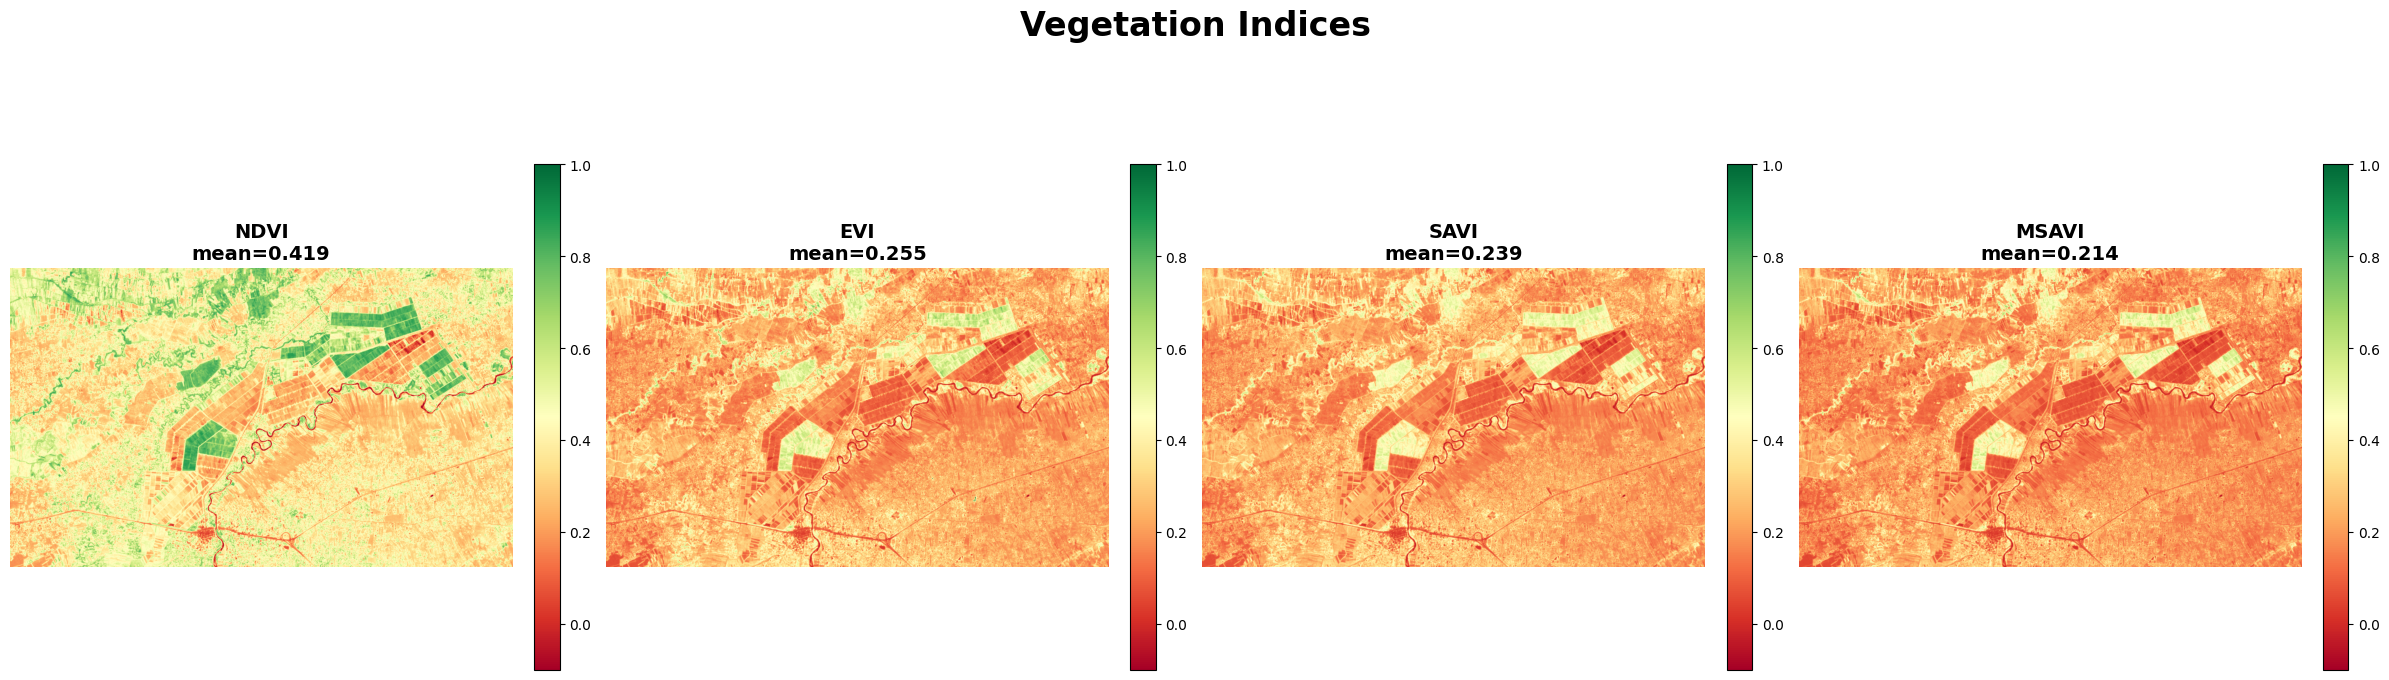

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(24, 8))

fig.suptitle(
    f"Vegetation Indices",
    fontsize=24, fontweight='bold'
)

cmap = plt.cm.RdYlGn
vmin, vmax = -0.1, 1.0

for ax, name in zip(axes, index_names):
    arr = indices_median[name]
    im = ax.imshow(arr.values, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(f"{name}\nmean={float(arr.mean()):.3f}", fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()